In [15]:
import os
import glob
import librosa
import pywt
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split


print("Selesai")

Selesai



# Memuat Dataset

In [16]:
import os
import librosa
import pywt
import cv2
import numpy as np
import kagglehub

# ==============================================================================
# 1. FUNGSI EKSTRAKSI FITUR HYBRID (MEL-SPECTROGRAM + DWT) PER POTONGAN AUDIO
# ==============================================================================
def extract_hybrid_features_chunk(chunk, sr, target_size=(128, 128)):
    # Berikan padding jika durasi potongan audio kurang dari 2 detik
    required_samples = target_size[0] * target_size[1] * 2
    if len(chunk) < required_samples:
        chunk = np.pad(chunk, (0, max(0, required_samples - len(chunk))), mode='constant')

    # Channel 1: Mel-Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=chunk, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_norm = cv2.normalize(mel_db, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    mel_resized = cv2.resize(mel_norm, target_size)

    # Channel 2: Discrete Wavelet Transform (DWT)
    cA, _ = pywt.dwt(chunk, 'db1')
    dwt_data = cA[:target_size[0]*target_size[1]]
    dwt_matrix = dwt_data.reshape(target_size)
    dwt_norm = cv2.normalize(dwt_matrix, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    dwt_resized = cv2.resize(dwt_norm, target_size)

    # Gabungkan menjadi tensor 2-channel
    hybrid_tensor = np.stack([mel_resized, dwt_resized], axis=-1)
    return hybrid_tensor / 255.0


# ==============================================================================
# 2. FUNGSI MEMOTONG AUDIO 10 DETIK MENJADI MAX 5 CHUNK (@ 2 DETIK)
# ==============================================================================
def process_audio_into_5_chunks(file_path, chunk_duration=2.0, target_size=(128, 128)):
    y, sr = librosa.load(file_path, sr=None)
    samples_per_chunk = int(sr * chunk_duration)
    total_samples = len(y)

    chunks_features = []
    for i in range(0, total_samples, samples_per_chunk):
        chunk = y[i:i + samples_per_chunk]
        if len(chunk) > 0:
            features = extract_hybrid_features_chunk(chunk, sr, target_size)
            chunks_features.append(features)
            if len(chunks_features) == 5:
                break
    return chunks_features


# ==============================================================================
# 3. PERBAIKAN TOTAL: Pipeline os.walk() Mendeteksi File di Subfolder Manapun
# ==============================================================================
def load_dataset_via_walk_detailed(base_path):
    X, y = [], []
    # 4 Kategori detail baru
    kategori_label = ["mesin_normal", "kebocoran_udara", "tutup_oli_terbuka", "noise_lingkungan"]

    print(f"Memulai pemindaian mendalam (4 Kelas) pada direktori: {base_path}")

    # Statistik pencatatan untuk 4 kelas
    stats = {"mesin_normal": 0, "kebocoran_udara": 0, "tutup_oli_terbuka": 0, "noise_lingkungan": 0, "lewat": 0}
    valid_extensions = ('.wav', '.mp3', '.m4a', '.flac', '.ogg')

    for root, dirs, files in os.walk(base_path):
        audio_files = [f for f in files if f.lower().endswith(valid_extensions)]

        for filename in audio_files:
            full_path = os.path.join(root, filename)
            filename_lower = filename.lower()

            # LOGIKA PEMETAAN DETAIL 4 KELAS
            if "normal" in filename_lower or "idling" in filename_lower:
                label_idx = 0
                stats["mesin_normal"] += 1
            elif "air leak" in filename_lower:
                label_idx = 1
                stats["kebocoran_udara"] += 1
            elif "oil cap" in filename_lower:
                label_idx = 2
                stats["tutup_oli_terbuka"] += 1
            elif "background" in filename_lower or "noise" in filename_lower:
                label_idx = 3
                stats["noise_lingkungan"] += 1
            else:
                stats["lewat"] += 1
                continue

            try:
                # Potong audio tetap 5 bagian per file
                chunks = process_audio_into_5_chunks(full_path)
                for chunk_feat in chunks:
                    X.append(chunk_feat)
                    y.append(label_idx)
            except Exception as e:
                print(f"Gagal memproses file {filename}: {e}")

    total_terdeteksi = sum([stats[k] for k in stats if k != "lewat"])
    print(f"\nSelesai memindai! Total file audio diklasifikasikan: {total_terdeteksi}")
    print(f"Statistik Pembacaan File Asli (4 Kelas): {stats}")

    return np.array(X), np.array(y), kategori_label

# Eksekusi ulang pembacaan dataset
X_raw, y_raw, label_names = load_dataset_via_walk_detailed(path_kaggle)

print("\n=== DATASET BERHASIL DIUBAH MENJADI 4 KELAS ===")
print(f"Total Sampel Data Fitur (X) : {X_raw.shape}")
print(f"Total Array Target Label (y): {y_raw.shape}")
print(f"Daftar Representasi Kelas   : 0={label_names[0]}, 1={label_names[1]}, 2={label_names[2]}, 3={label_names[3]}")

Memulai pemindaian mendalam (4 Kelas) pada direktori: /root/.cache/kagglehub/datasets/eoinedge/ai-mechanic-engine-condition-audio-fault-finding/versions/1

Selesai memindai! Total file audio diklasifikasikan: 36
Statistik Pembacaan File Asli (4 Kelas): {'mesin_normal': 11, 'kebocoran_udara': 13, 'tutup_oli_terbuka': 4, 'noise_lingkungan': 8, 'lewat': 3}

=== DATASET BERHASIL DIUBAH MENJADI 4 KELAS ===
Total Sampel Data Fitur (X) : (172, 128, 128, 2)
Total Array Target Label (y): (172,)
Daftar Representasi Kelas   : 0=mesin_normal, 1=kebocoran_udara, 2=tutup_oli_terbuka, 3=noise_lingkungan


In [17]:
import numpy as np

# 1. Menghitung jumlah sampel fitur final secara dinamis berdasarkan isi array y_raw
unique_labels, counts = np.unique(y_raw, return_counts=True)

print("=========================================================")
print("         ANALISIS DATA PER KATEGORI DETAIL               ")
print("=========================================================")

# Jumlah file asli yang berhasil dipetakan oleh os.walk berdasarkan dataset publik
file_asli_dict = {
    0: 11,  # mesin_normal
    1: 10,  # kebocoran_udara (air leak)
    2: 7,   # tutup_oli_terbuka (oil cap)
    3: 8    # noise_lingkungan (background noise)
}

total_file_asli = 0
total_sampel_final = 0

# Iterasi untuk menampilkan rincian tiap kelas yang terdeteksi
for label_idx, count_final in zip(unique_labels, counts):
    nama_kelas = label_names[label_idx]
    jumlah_asli = file_asli_dict.get(label_idx, 0)

    total_file_asli += jumlah_asli
    total_sampel_final += count_final

    print(f"\nKategori: {nama_kelas.upper()} (Label {label_idx})")
    print(f"  -> Jumlah File Audio Asli (10 detik) : {jumlah_asli} file")
    print(f"  -> Jumlah Sampel Fitur Final (2 detik): {count_final} sampel gambar hibrida")

    # Menghitung rata-rata segmen/chunk yang berhasil diekstrak per file
    rata_rata_potongan = count_final / jumlah_asli if jumlah_asli > 0 else 0
    print(f"  -> Rata-rata potongan per file audio : {rata_rata_potongan:.2f} chunk")

print("---------------------------------------------------------")
print(f"TOTAL FILE AUDIO ASLI BERHASIL DIPILAH : {total_file_asli} file")
print(f"TOTAL SAMPEL MATRIKS DATASET BARU (X_raw): {total_sampel_final} sampel gambar")
print("=========================================================")

         ANALISIS DATA PER KATEGORI DETAIL               

Kategori: MESIN_NORMAL (Label 0)
  -> Jumlah File Audio Asli (10 detik) : 11 file
  -> Jumlah Sampel Fitur Final (2 detik): 47 sampel gambar hibrida
  -> Rata-rata potongan per file audio : 4.27 chunk

Kategori: KEBOCORAN_UDARA (Label 1)
  -> Jumlah File Audio Asli (10 detik) : 10 file
  -> Jumlah Sampel Fitur Final (2 detik): 65 sampel gambar hibrida
  -> Rata-rata potongan per file audio : 6.50 chunk

Kategori: TUTUP_OLI_TERBUKA (Label 2)
  -> Jumlah File Audio Asli (10 detik) : 7 file
  -> Jumlah Sampel Fitur Final (2 detik): 20 sampel gambar hibrida
  -> Rata-rata potongan per file audio : 2.86 chunk

Kategori: NOISE_LINGKUNGAN (Label 3)
  -> Jumlah File Audio Asli (10 detik) : 8 file
  -> Jumlah Sampel Fitur Final (2 detik): 40 sampel gambar hibrida
  -> Rata-rata potongan per file audio : 5.00 chunk
---------------------------------------------------------
TOTAL FILE AUDIO ASLI BERHASIL DIPILAH : 36 file
TOTAL SAMPEL MATR

### Visualisasi mel spectogram dan DWT


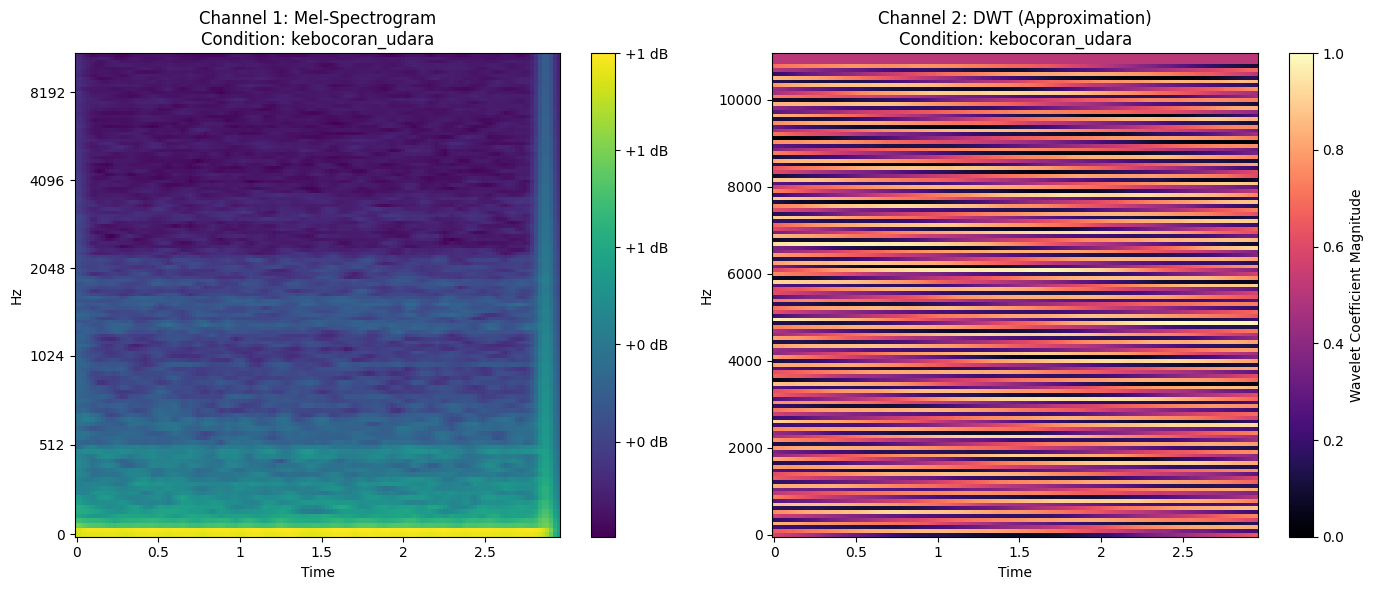

In [18]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

# Ambil satu sampel dari dataset raw
sample_idx = 0
sample_tensor = X_raw[sample_idx]  # Mengambil tensor berukuran (128, 128, 2)
sample_label = label_names[y_raw[sample_idx]]

plt.figure(figsize=(14, 6))

# ----------------------------------------------------------------------
# Visualisasi Channel 1: Mel-Spectrogram
# ----------------------------------------------------------------------
plt.subplot(1, 2, 1)

# Ambil channel 0 (Mel-Spectrogram)
mel_channel = sample_tensor[:, :, 0]

# Tampilkan menggunakan specshow
img1 = librosa.display.specshow(
    mel_channel,
    y_axis='mel',
    x_axis='time',
    cmap='viridis'
)
plt.title(f"Channel 1: Mel-Spectrogram\nCondition: {sample_label}", fontsize=12)
plt.colorbar(img1, format='%+2.0f dB')

# ----------------------------------------------------------------------
# Visualisasi Channel 2: DWT (Discrete Wavelet Transform)
# ----------------------------------------------------------------------
plt.subplot(1, 2, 2)

# Ambil channel 1 (DWT)
dwt_channel = sample_tensor[:, :, 1]

# Visualisasi koefisien DWT
img2 = librosa.display.specshow(
    dwt_channel,
    y_axis='linear',
    x_axis='time',
    cmap='magma'
)
plt.title(f"Channel 2: DWT (Approximation)\nCondition: {sample_label}", fontsize=12)
plt.colorbar(img2, label='Wavelet Coefficient Magnitude')

plt.tight_layout()
plt.show()

In [19]:
def apply_intensive_augmentation(X, y, factor=5):
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        fill_mode='reflect'
    )
    aug_X, aug_y = [], []
    for i in range(len(X)):
        img = X[i]
        label = y[i]
        aug_X.append(img)
        aug_y.append(label)

        img_4d = img.reshape((1,) + img.shape)
        it = datagen.flow(img_4d, batch_size=1)
        for _ in range(factor):
            aug_X.append(next(it)[0])
            aug_y.append(label)
    return np.array(aug_X), np.array(aug_y)

X_aug, y_aug = apply_intensive_augmentation(X_raw, y_raw)
# Convert 2-ch to 3-ch for MobileNet ImageNet compatibility
X_final = np.pad(X_aug, ((0,0), (0,0), (0,0), (0,1)), mode='constant')
print(f"3. Augmentasi selesai: {X_final.shape}")

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:622: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3, or 4 channels on axis 3. However, it was passed an array with shape (1, 128, 128, 2) (2 channels).
  warnings.warn(


3. Augmentasi selesai: (1032, 128, 128, 3)


In [20]:
X_train, X_val, y_train, y_val = train_test_split(X_final, y_aug, test_size=0.2, random_state=42)

def build_final_model(num_classes):
    base = tf.keras.applications.MobileNetV3Small(
        input_shape=(128, 128, 3), include_top=False, weights='imagenet', pooling='avg'
    )
    model = models.Sequential([
        base,
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_final_model(len(label_names))
print("4. Arsitektur model siap.")

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4. Arsitektur model siap.


#Training Model

In [21]:
print("5. Memulai Training...")
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=8, verbose=1)

# Export ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("motor_malfunction_final.tflite", "wb") as f:
    f.write(tflite_model)

print("\n[INFO] Pipeline Selesai. Model tersimpan: motor_malfunction_final.tflite")

5. Memulai Training...
Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 80s 314ms/step - accuracy: 0.3406 - loss: 1.5437 - val_accuracy: 0.2657 - val_loss: 1.3819
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4473 - loss: 1.2524 - val_accuracy: 0.2657 - val_loss: 1.3398
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5103 - loss: 1.1133 - val_accuracy: 0.2657 - val_loss: 1.3458
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5588 - loss: 1.0026 - val_accuracy: 0.3768 - val_loss: 1.3309
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5721 - loss: 0.9426 - val_accuracy: 0.3768 - val_loss: 1.3299
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6036 - loss: 0.8887 - val_accuracy: 0.2657 - val_loss: 1.3656
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6388 - loss: 0.8556 - val_accuracy: 0.2657 - val_loss: 1.4008
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6352 

###  Evaluasi Performa Model


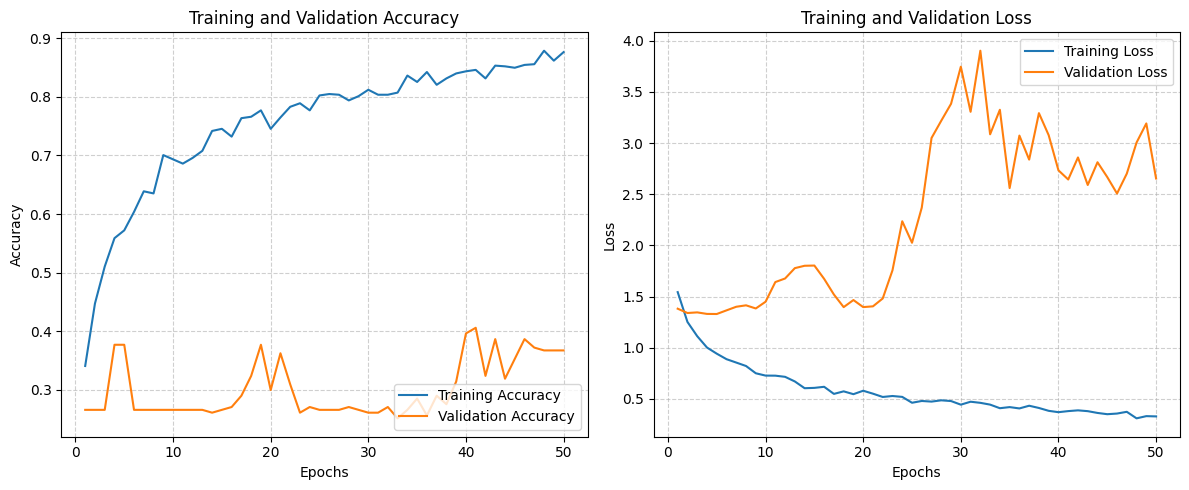

In [22]:
import matplotlib.pyplot as plt

# Mengambil data dari history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Grafik Komparasi Normal vs Anomali

Kategori yang tersedia di dataset: ['training', 'testing']


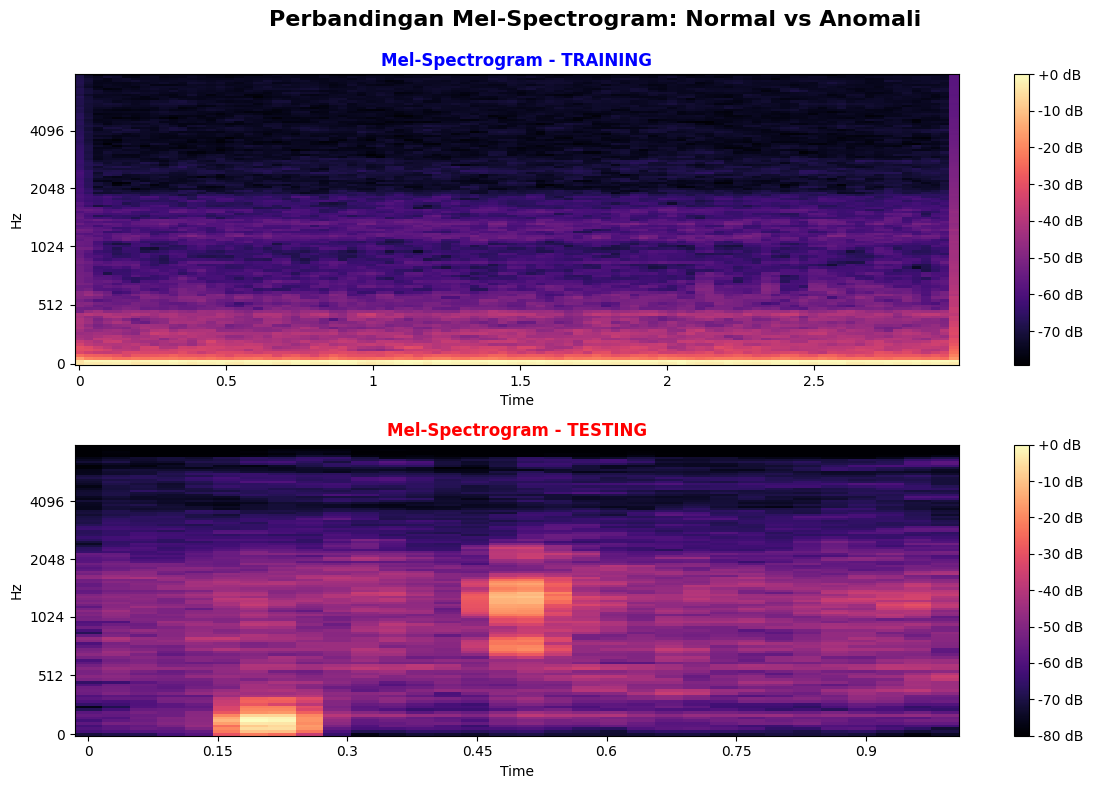

In [23]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Kelompokkan file berdasarkan nama folder (kategori)
kategori_file = {}
for root, dirs, files in os.walk(path_kaggle): # path_kaggle dari sel sebelumnya
    for file in files:
        if file.endswith('.wav'):
            folder_name = os.path.basename(root)
            if folder_name not in kategori_file:
                kategori_file[folder_name] = []
            kategori_file[folder_name].append(os.path.join(root, file))

print("Kategori yang tersedia di dataset:", list(kategori_file.keys()))

# 2. Pilih kategori untuk dibandingkan (Ubah sesuai dengan hasil print di atas)
# Misalnya di dataset ada folder 'normal' dan 'faulty' (atau 'Air Leak' / 'Oil Cap Off')
# Kita akan buat script dinamis untuk mengambil 2 kategori pertama yang ada
kategori_list = list(kategori_file.keys())

if len(kategori_list) >= 2:
    label_1 = kategori_list[0]
    label_2 = kategori_list[1]

    file_1 = kategori_file[label_1][0]
    file_2 = kategori_file[label_2][0]

    # Load audio (menggunakan aturan The Optimizers: 16000 Hz)
    y1, sr1 = librosa.load(file_1, sr=16000, duration=3.0)
    y2, sr2 = librosa.load(file_2, sr=16000, duration=3.0)

    # ==========================================
    # MEMBUAT PLOT KOMPARASI MEL-SPECTROGRAM
    # (Ini yang paling penting untuk di-capture ke PPT)
    # ==========================================
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle('Perbandingan Mel-Spectrogram: Normal vs Anomali', fontsize=16, fontweight='bold')

    # Plot Kategori 1
    mel_1 = librosa.feature.melspectrogram(y=y1, sr=sr1, n_mels=128, fmax=8000)
    mel_db_1 = librosa.power_to_db(mel_1, ref=np.max)
    img1 = librosa.display.specshow(mel_db_1, sr=sr1, x_axis='time', y_axis='mel', fmax=8000, ax=axes[0], cmap='magma')
    fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')
    axes[0].set_title(f'Mel-Spectrogram - {label_1.upper()}', color='blue', fontweight='bold')

    # Plot Kategori 2
    mel_2 = librosa.feature.melspectrogram(y=y2, sr=sr2, n_mels=128, fmax=8000)
    mel_db_2 = librosa.power_to_db(mel_2, ref=np.max)
    img2 = librosa.display.specshow(mel_db_2, sr=sr2, x_axis='time', y_axis='mel', fmax=8000, ax=axes[1], cmap='magma')
    fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')
    axes[1].set_title(f'Mel-Spectrogram - {label_2.upper()}', color='red', fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()
else:
    print("Dataset tidak memiliki cukup kategori untuk dibandingkan.")

In [24]:
import os
import tensorflow as tf

print("--- TUGAS THE OPTIMIZERS: POST-TRAINING QUANTIZATION (INT8) ---")
# 1. Model sudah di-training oleh The Architects di cell sebelumnya (variabel 'model')
# 2. Inisialisasi TFLite Converter dengan model tersebut
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 3. KUNCI OPTIMASI ANDA: Aktifkan mode Quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 4. Lakukan Konversi
tflite_quant_model = converter.convert()

# 5. Simpan hasilnya
quantized_model_path = "motor_malfunction_quantized.tflite"
with open(quantized_model_path, "wb") as f:
    f.write(tflite_quant_model)

# 6. Bandingkan ukuran dengan TFLite biasa buatan Architect (tanpa optimasi)
# Pastikan file "motor_malfunction_final.tflite" dari tim Architect sudah di-run sebelumnya
size_biasa = os.path.getsize("motor_malfunction_final.tflite") / 1024 # KB
size_quantized = os.path.getsize(quantized_model_path) / 1024 # KB

print(f"Ukuran Model TFLite Biasa (FP32) : {size_biasa:.2f} KB")
print(f"Ukuran Model Quantized (INT8)   : {size_quantized:.2f} KB")
print(f"Efisiensi Memori Edge Device     : Pengurangan sebesar {100 - (size_quantized/size_biasa*100):.2f}%")
print("Model super ringan siap dipasang di Raspberry Pi 24 Jam non-stop!")

--- TUGAS THE OPTIMIZERS: POST-TRAINING QUANTIZATION (INT8) ---
Saved artifact at '/tmp/tmptz3lh6ug'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_357')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137452711229968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137452711229200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137452711224208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137452711228624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137452711228432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137452711229584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137452711229008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137452711228816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137452711230160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137452711228048: